In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data

In [48]:
df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

sequels = df[df["part"] > 0].copy()
originals = df[df["part"] == 0].copy()

In [49]:
print(f"Franchises: {df['collection_id'].nunique()}")
print(f"Originals:  {len(originals)}")
print(f"Sequels:    {len(sequels)}")

Franchises: 162
Originals:  162
Sequels:    252


### Sanity check

In [50]:
df[["budget", "revenue", "roi", "rating"]].describe(percentiles=[0.05, 0.5, 0.95])

,budget,revenue,roi,rating
count,4.140000e+02,4.140000e+02,414.000000,414.000000
mean,1.072586e+08,4.688453e+08,5.755435,6.802314
std,8.298560e+07,4.258595e+08,7.424032,0.683861
min,3.500000e+04,4.217980e+05,0.080000,4.610000
5%,8.000000e+06,2.174568e+07,1.273000,5.753150
50%,9.100000e+07,3.719425e+08,4.140000,6.743500
95%,2.500000e+08,1.222725e+09,12.777000,7.862000
max,4.899000e+08,2.923706e+09,86.700000,8.527000


## Financial success

### Originals vs. Sequels

In [59]:
# Average performance: Originals vs. Sequels
comparison = pd.DataFrame({
    "Original": originals[["revenue", "roi", "rating"]].mean(),
    "Sequel":   sequels[["revenue", "roi", "rating"]].mean()
})

# How many sequels outperform vs. underperform their original?
n_better = (sequels["revenue_diff"] > 0).sum()
n_worse  = (sequels["revenue_diff"] < 0).sum()

print(f"Sequels with higher revenue than original:  {n_better}")
print(f"Sequels with lower revenue than original:   {n_worse}")
print(f"Share outperforming: {n_better / (n_better + n_worse) * 100:.1f}%")

comparison

Sequels with higher revenue than original:  128
Sequels with lower revenue than original:   124
Share outperforming: 50.8%


,Original,Sequel
revenue,4.338161e+08,4.913641e+08
roi,6.696296e+00,5.150595e+00
rating,6.887790e+00,6.747365e+00


### Top 10 Franchises with Performane increase 

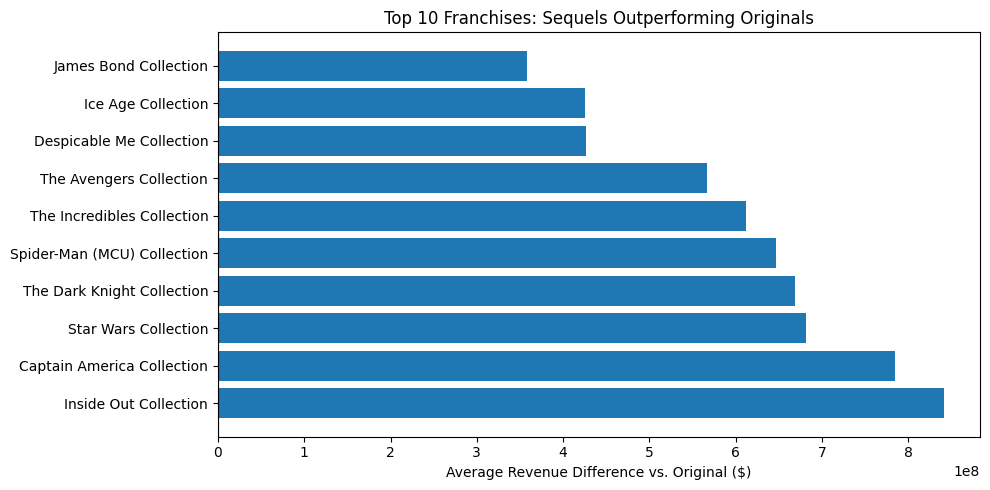

In [53]:
top_growth = (
    sequels.groupby("collection_name")["revenue_diff"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10, 5))
plt.barh(top_growth.index, top_growth.values)
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Average Revenue Difference vs. Original ($)")
plt.title("Top 10 Franchises: Sequels Outperforming Originals")
plt.tight_layout()
plt.show()

## Financial and Rating

### Original vs. Sequel: Financial and Critical Performance

/tmp/ipykernel_926/3343062354.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_926/3343062354.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(
/tmp/ipykernel_926/3343062354.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


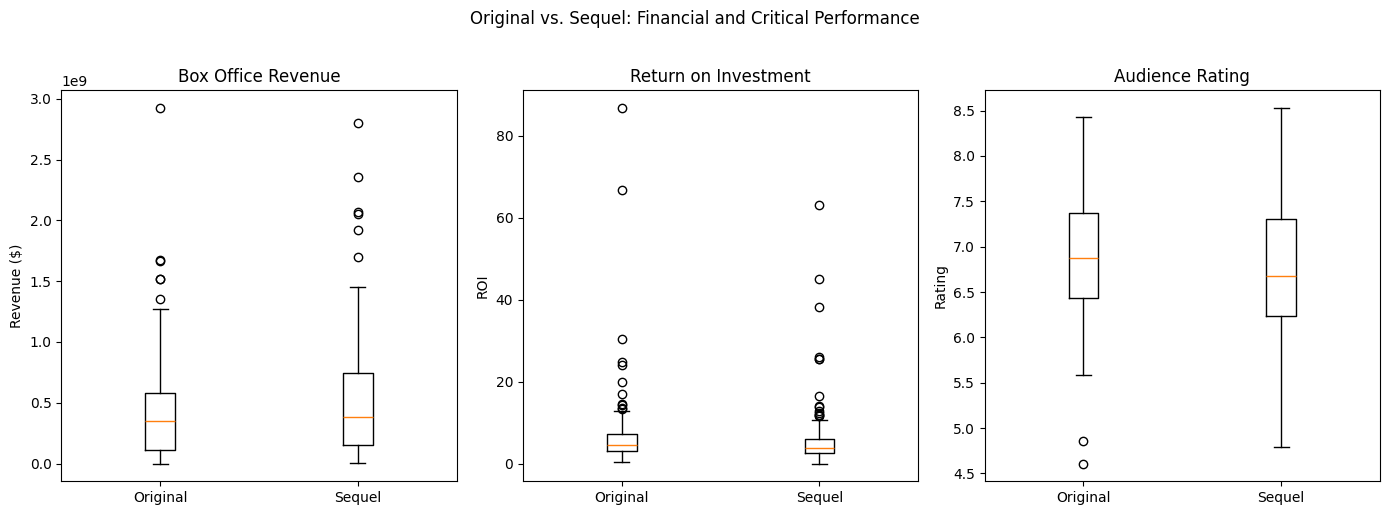

In [54]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ("revenue",  "Revenue ($)",   "Box Office Revenue"),
    ("roi",      "ROI",           "Return on Investment"),
    ("rating",   "Rating",        "Audience Rating"),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    ax.boxplot(
        [originals[col].dropna(), sequels[col].dropna()],
        labels=["Original", "Sequel"]
    )
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.suptitle("Original vs. Sequel: Financial and Critical Performance", y=1.02)
plt.tight_layout()
plt.show()

### Performance by Sequel Number

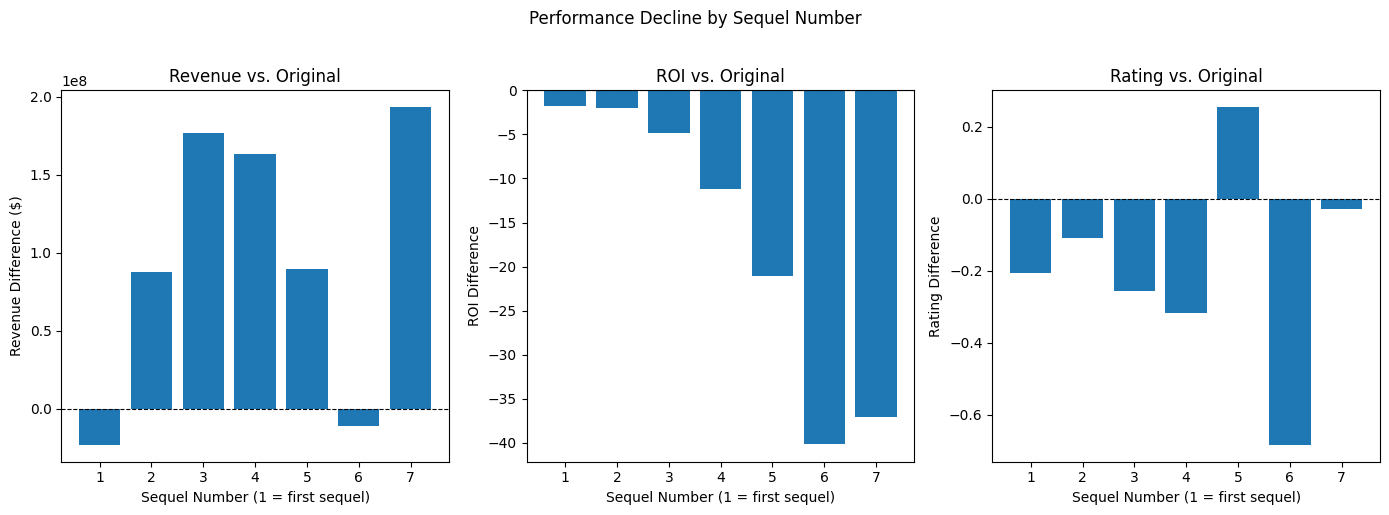

,part,n_films,revenue_diff,roi_diff,rating_diff
0,1,162,-2.327357e+07,-1.758519,-0.207346
1,2,52,8.782423e+07,-2.010577,-0.109981
2,3,21,1.764653e+08,-4.809524,-0.256476
3,4,9,1.632040e+08,-11.235556,-0.317333
4,5,4,8.912721e+07,-21.117500,0.253500
5,6,2,-1.099605e+07,-40.135000,-0.683000
6,7,2,1.931548e+08,-37.070000,-0.029500


In [55]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = [
    ("revenue_diff", "Revenue Difference ($)", "Revenue vs. Original"),
    ("roi_diff",     "ROI Difference",          "ROI vs. Original"),
    ("rating_diff",  "Rating Difference",        "Rating vs. Original"),
]

for ax, (col, ylabel, title) in zip(axes, metrics):
    ax.bar(by_part["part"], by_part[col])
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xlabel("Sequel Number (1 = first sequel)")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

plt.suptitle("Performance Decline by Sequel Number", y=1.02)
plt.tight_layout()
plt.show()

by_part = sequels.groupby("part").agg(
    n_films      = ("revenue_diff", "count"),
    revenue_diff = ("revenue_diff", "mean"),
    roi_diff     = ("roi_diff",     "mean"),
    rating_diff  = ("rating_diff",  "mean")
).reset_index()

by_part

## Rating

### correleation Ratingperformance & Earnings: originals vs sequels

In [56]:
corr = sequels[["revenue_diff", "roi_diff", "rating_diff"]].corr()
corr

,revenue_diff,roi_diff,rating_diff
revenue_diff,1.000000,0.117349,0.137921
roi_diff,0.117349,1.000000,0.302999
rating_diff,0.137921,0.302999,1.000000


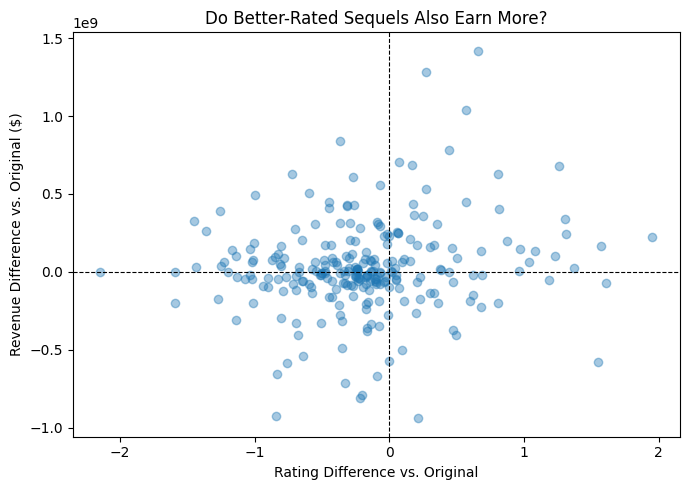

In [57]:
plt.figure(figsize=(7, 5))
plt.scatter(sequels["rating_diff"], sequels["revenue_diff"], alpha=0.4)
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.axvline(0, color="black", linewidth=0.8, linestyle="--")
plt.xlabel("Rating Difference vs. Original")
plt.ylabel("Revenue Difference vs. Original ($)")
plt.title("Do Better-Rated Sequels Also Earn More?")
plt.tight_layout()
plt.show()

## Take away

In [58]:
summary = pd.DataFrame({
    "Metric": ["Revenue Diff", "ROI Diff", "Rating Diff", "Better Revenue", "Better Rating"],
    "Value": [
        f"${sequels['revenue_diff'].mean():,.0f}",
        f"{sequels['roi_diff'].mean():.2f}",
        f"{sequels['rating_diff'].mean():.3f}",
        f"{(sequels['revenue_diff'] > 0).mean() * 100:.1f}%",
        f"{(sequels['rating_diff'] > 0).mean() * 100:.1f}%",
    ]
})
print("On average, sequels underperform their originals financially and critically \n — but with a near 50/50 split, success is highly franchise-dependent.")
summary



On average, sequels underperform their originals financially and critically 
 — but with a near 50/50 split, success is highly franchise-dependent.


,Metric,Value
0,Revenue Diff,"$26,555,460"
1,ROI Diff,-3.30
2,Rating Diff,-0.190
3,Better Revenue,50.8%
4,Better Rating,28.6%
